In [ ]:
#Importing Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import ast

#Loading Dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda skill_list: ast.literal_eval(skill_list) if pd.notna(skill_list) else skill_list)

In [ ]:
#Filter for data analyst
df_DA = df[df['job_title_short']=='Data Analyst'].copy()

In [14]:
df_DA['job_posted_month_no']=df_DA['job_posted_date'].dt.month
df_DA.head()
df_DA_explode = df_DA.explode('job_skills')
df_DA_pivot = df_DA_explode.pivot_table(index='job_posted_month_no',columns = "job_skills",aggfunc="size",fill_value=0) #fill_value attribute in order to eliminate Nan
# df_DA_pivot.plot(kind="bar"), too big

#we want to create a row called 'Total' that sums up all the rows
df_DA_pivot.loc['Total'] = df_DA_pivot.sum()

#We then sort the values by the Total row in order to get the most sought-after skills
#We then use the '.index' method to get a list of most sought-after skills in that order
#We then pass that as a list in itself into the call of df_DA_pivot to have the table be presented in that order
df_DA_pivot = df_DA_pivot[df_DA_pivot.loc['Total'].sort_values(ascending=False).index]

df_DA_pivot = df_DA_pivot.drop('Total')
df_DA_pivot

#Can turn numbers into months, was done before, look it up

job_skills,sql,excel,python,tableau,power bi,r,sas,powerpoint,word,sap,...,xamarin,mattermost,gtx,esquisse,chainer,capacitor,nuxt.js,msaccess,ovh,suse
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,11336,8170,6606,5596,4285,3607,3830,1880,1778,1251,...,0,0,0,0,0,1,1,0,0,0
2,7947,5772,4751,3936,3307,2576,2634,1291,1235,954,...,0,0,0,0,0,0,0,0,0,0
3,7868,5675,4741,4051,3176,2650,2554,1266,1203,892,...,1,0,0,0,0,0,0,0,0,1
4,7553,5496,4557,3776,3106,2399,2598,1190,1177,947,...,0,0,0,0,0,0,0,0,1,0
5,6617,4773,4070,3245,2695,2093,1940,979,957,851,...,0,0,0,0,0,0,0,1,0,0
6,7584,5724,4707,3812,3275,2442,2174,1173,1237,987,...,0,0,0,0,0,0,0,0,0,0
7,7687,5513,4831,3928,3350,2444,2118,1096,1069,996,...,0,0,1,0,0,0,0,0,0,0
8,8823,6482,5576,4533,3859,2975,2560,1332,1298,1117,...,0,0,0,0,0,0,0,0,0,0
9,6829,4886,4229,3446,3118,2146,1880,944,945,852,...,0,1,0,0,0,0,0,0,0,0


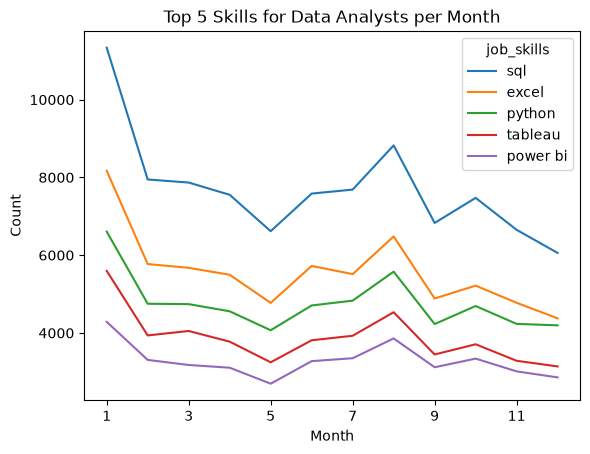

In [15]:
df_DA_pivot.iloc[:,:5].plot(kind="line")
plt.ylabel("Count")
plt.xlabel("Month")
plt.title("Top 5 Skills for Data Analysts per Month")
plt.show()

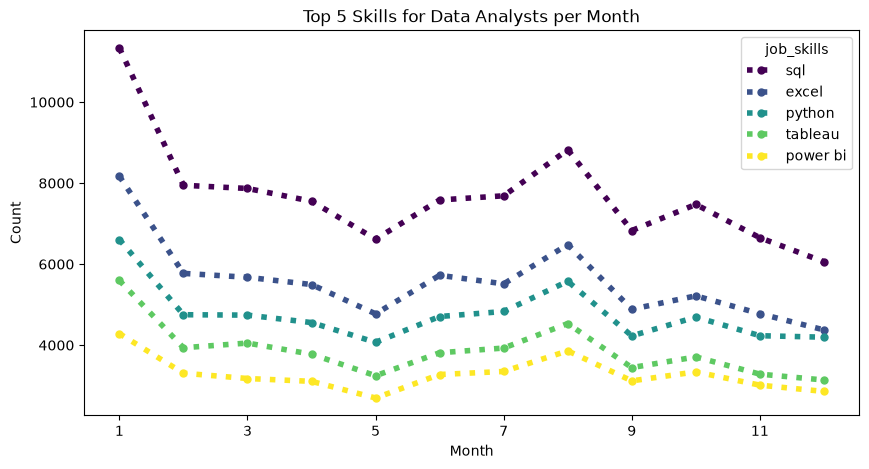

In [22]:
df_DA_pivot.iloc[:,:5].plot(
    kind='line',
    linewidth=4,
    linestyle=':', #options; '-','--','-.',':'
    colormap='viridis',
    marker='o', #options; 'o','x','+','*','s',',','.','1/2/3'...
    markersize=5,
    figsize = (10,5)
    )
plt.ylabel("Count")
plt.xlabel("Month")
plt.title("Top 5 Skills for Data Analysts per Month")

plt.show()

# Customizing Scatter Plots (Lesson 15)

In [23]:
df_skills = df[df['job_title_short']=='Data Analyst'].copy()
df_skills = df_skills.explode('job_skills')
# skills_count = df_skills.groupby(['job_skills']).size()
# df_skills_count = skills_count.reset_index(name='skill_count')
# df_skills_count.sort_values(by='skill_count',ascending=False,inplace=True)

# df_skills_count = df_skills_count.reset_index().head(10)
# #df_skills_count.drop(columns=['index'])
# df_skills_count.drop('index', axis=1, inplace=True)
# df_skills_count['median_salary'] = df.groupby['salary_year_avg'].median()


skills_stats = (
    df_skills
    .groupby('job_skills')
    .agg(
        skill_count=('job_skills', 'size'),
        median_salary=('salary_year_avg', 'median')
    )
    .sort_values(by='skill_count', ascending=False)
    .head(20)
)

In [26]:
from adjustText import adjust_text

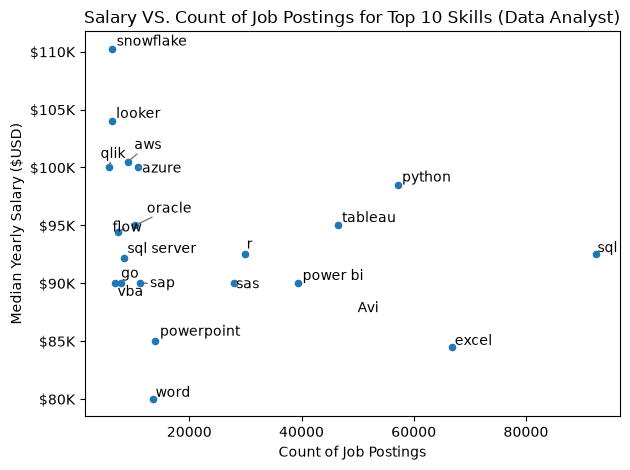

In [36]:
skills_stats.plot(kind='scatter',x='skill_count',y='median_salary')
#plt.text(x,y,string) example
plt.text(50000,87500,'Avi')
texts = []
for i, txt in enumerate(skills_stats.index):
    #trying to break it down into stages, we first want to print out the X,y values per i
    texts.append(plt.text(skills_stats['skill_count'].iloc[i],
             skills_stats['median_salary'].iloc[i],
             txt))
adjust_text(texts,  arrowprops=dict(arrowstyle='->', color='gray', lw=1))
#    print(i,txt)

ax = plt.gca() #gca = get current axis, to access y axis to change values and add '$'
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))

plt.xlabel('Count of Job Postings')
plt.ylabel('Median Yearly Salary ($USD)')
plt.title('Salary VS. Count of Job Postings for Top 10 Skills (Data Analyst)')
plt.tight_layout()
plt.show()